<a href="https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/Alignment_Trimming_ClipKIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/Alignment_Trimming_ClipKIT.ipynb)


# Automated Protein Alignment Trimming with ClipKIT

**Workflow:** taxon-directed homolog search → Clustal Omega on Pete → **this notebook** → RAxML on Pete.

Open this notebook in Colab, then use **File → Save a copy in Drive** and place your copy in your course `Notebooks` folder. Run the numbered sections in order. ClipKIT installs in the temporary Colab runtime; your inputs and results persist on Drive.

### How to use

1. **Once:** run Section 0 to create the folders, then drop your aligned protein FASTA files into the `alignments/` folder it makes.
2. **Each run:** in Section 1 set `ALIGNMENT_FASTA` to the file you want, then **Runtime ▸ Run all**. The cleaned alignment and tables appear in `Outputs/…`, figures in `Reports/…`.
3. **Advanced — compare trimming settings:** change `MODE`/`GAP_THRESHOLD` **and** give `RUN_LABEL` a new name, then run again; each setting is saved in its own folder.

This notebook follows the folder conventions in `NB03.2_taxon-directed_BLASTsearch.ipynb`. It consumes an **already aligned protein FASTA**, not the BLAST hits FASTA. It does not contact Pete, retrieve proteins, or rebuild databases.

We remove columns using gap-based criteria, not simply because they are constant or variable. Automated trimming is not proof of correct homology. Review coverage and unusually extensive trimming before phylogenetic analysis.

## 0. Setup — mount Drive and create this notebook's folders

Run this first. It creates the folder structure on your Drive, so you can drop your aligned FASTA files in before running anything else. `PROJECT_DRIVE` and `COLLECTION` are set here (the only place). `Databases` is the shared reference area; ClipKIT needs no database and does not touch it.

```text
BIOINFO4-5203-F26/
  Data/Alignment_Trimming_ClipKIT/alignments/        # DROP your aligned FASTA files here (persistent)
  Outputs/Alignment_Trimming_ClipKIT/<QUERY_NAME>/<RUN_LABEL>/<execution>/   # cleaned FASTA + tables
  Reports/Alignment_Trimming_ClipKIT/<QUERY_NAME>/<RUN_LABEL>/<execution>/   # figures + summary
  Notebooks/                                          # saved student notebook copies
```
Keep all your aligned FASTAs in the one `alignments/` folder and name the one to trim in Section 1. Each run is saved under its own unique `<execution>` folder, so earlier results are never overwritten.

In [2]:
from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path

# ---- LOCATION (the only place these are set) ----
PROJECT_DRIVE = "/content/drive/MyDrive/BIOINFO4-5203-F26"   # your project folder on Drive
COLLECTION    = "Alignment_Trimming_ClipKIT"                 # this notebook's Data/Outputs/Reports subfolder

PROJECT   = Path(PROJECT_DRIVE)
ALIGN_DIR = PROJECT / "Data" / COLLECTION / "alignments"     # PERSISTENT: drop your aligned FASTA files here
for d in (ALIGN_DIR,
          PROJECT / "Outputs" / COLLECTION,
          PROJECT / "Reports" / COLLECTION,
          PROJECT / "Notebooks"):
    d.mkdir(parents=True, exist_ok=True)
DB_ROOT = PROJECT / "Databases"   # shared reference area; not needed or modified by this notebook

print("Project folders ready under:", PROJECT)
print("  input  (drop aligned FASTAs here) ->", ALIGN_DIR)
print("  output (results)                  ->", PROJECT / "Outputs" / COLLECTION)
print("  reports (figures/summaries)       ->", PROJECT / "Reports" / COLLECTION)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folders ready under: /content/drive/MyDrive/BIOINFO4-5203-F26
  input  (drop aligned FASTAs here) -> /content/drive/MyDrive/BIOINFO4-5203-F26/Data/Alignment_Trimming_ClipKIT/alignments
  output (results)                  -> /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/Alignment_Trimming_ClipKIT
  reports (figures/summaries)       -> /content/drive/MyDrive/BIOINFO4-5203-F26/Reports/Alignment_Trimming_ClipKIT


## 1. Install ClipKIT and configure this run

Installs the pinned ClipKIT version (rerun after a runtime reset). Then set which alignment to trim:

- `ALIGNMENT_FASTA` — the **filename** of an aligned FASTA already in your `alignments/` folder (the only required edit).
- `QUERY_NAME` — label for the output folders; leave **blank** to name it automatically from the file, or set it (e.g. to match your BLAST notebook).
- `RUN_LABEL` — names the results subfolder for this parameter set; change it when comparing trimming settings so runs are saved side by side.
- `MODE` — `smart-gap` chooses a gap threshold from the alignment; `gappy` uses your explicit `GAP_THRESHOLD`.

Missing characters are `X`, `?`, and `-`; ambiguous `B/Z/J` residues are reported separately and stops are rejected for review. Optional `SOURCE_METADATA` points to the BLAST summary CSV, copied unchanged for provenance.

In [6]:
import sys, subprocess, importlib.metadata
CLIPKIT_VERSION = "2.7.0"
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                f"clipkit=={CLIPKIT_VERSION}", "biopython==1.85", "matplotlib"], check=True)
print("Installed ClipKIT:", importlib.metadata.version("clipkit"))

# ============================================================================
# INPUTS  —  which aligned FASTA to trim
# ============================================================================
ALIGNMENT_FASTA = "CytC-homologs-Aln2.fasta"   # filename of an aligned FASTA already in your alignments/ folder
QUERY_NAME      = ""                         # label for the output folders. BLANK = auto (filename without extension)
RUN_LABEL       = "smart_gap_v1"            # names the RESULTS subfolder for THIS trimming setting

# ============================================================================
# TRIMMING PARAMETERS
# ============================================================================
MODE          = "smart-gap"   # "smart-gap" (threshold chosen from the alignment) or "gappy" (your threshold)
GAP_THRESHOLD = 0.8           # only used when MODE = "gappy"; gap fraction (0-1) above which a column is removed

# ============================================================================
# ADVANCED
# ============================================================================
SOURCE_METADATA = ""          # optional: full Drive path to the BLAST summary CSV, copied unchanged for provenance


Installed ClipKIT: 2.7.0


## 2. Locate the input and prepare the run

Finds `ALIGNMENT_FASTA` in your `alignments/` folder. If the name doesn't match, it lists the aligned FASTAs that **are** there so you can fix `ALIGNMENT_FASTA` in Section 1 — nothing runs on a missing file. Sets `QUERY_NAME` (from the filename if you left it blank) and prints a one-line summary. Alternatively set `UPLOAD_FROM_COMPUTER = True` to pick the file from your computer; it saves a persistent copy into `alignments/` and refuses to overwrite a different file with the same name.

In [7]:
import re, hashlib, shutil

# basic parameter checks
if Path(ALIGNMENT_FASTA).name != ALIGNMENT_FASTA or not ALIGNMENT_FASTA:
    raise ValueError("ALIGNMENT_FASTA must be a filename (in your alignments/ folder), not a path.")
if MODE not in {"smart-gap", "gappy"} or not 0 <= GAP_THRESHOLD <= 1:
    raise ValueError("Check MODE (smart-gap/gappy) and GAP_THRESHOLD (0-1).")

# optional: upload the alignment from your computer straight into the persistent alignments/ folder
UPLOAD_FROM_COMPUTER = False
if UPLOAD_FROM_COMPUTER:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1 or ALIGNMENT_FASTA not in uploaded:
        raise ValueError("Upload exactly the one file named in ALIGNMENT_FASTA (Section 1).")
    dest = ALIGN_DIR / ALIGNMENT_FASTA
    if dest.exists() and dest.read_bytes() != uploaded[ALIGNMENT_FASTA]:
        raise FileExistsError(f"A different file named {ALIGNMENT_FASTA} already exists in {ALIGN_DIR}.")
    dest.write_bytes(uploaded[ALIGNMENT_FASTA])

# resolve the input from the persistent alignments/ folder
INPUT = ALIGN_DIR / ALIGNMENT_FASTA
if not INPUT.is_file():
    available = sorted(p.name for p in ALIGN_DIR.glob("*.f*a")) or ["(none yet - drop a FASTA in)"]
    raise FileNotFoundError(
        f"'{ALIGNMENT_FASTA}' not found in {ALIGN_DIR}\n"
        f"Aligned FASTA files available there:\n  " + "\n  ".join(available) +
        f"\nSet ALIGNMENT_FASTA (Section 1) to one of these, or drop the file into that folder.")

# label for the output folders: auto from the filename unless QUERY_NAME was set
QUERY_NAME = QUERY_NAME.strip() or Path(ALIGNMENT_FASTA).stem
for label, value in (("COLLECTION", COLLECTION), ("QUERY_NAME", QUERY_NAME), ("RUN_LABEL", RUN_LABEL)):
    if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]*", value):
        raise ValueError(f"{label} = '{value}': use only letters, numbers, underscores, dots, or hyphens "
                         f"(set QUERY_NAME explicitly in Section 1 if the filename is not a clean label).")

if SOURCE_METADATA and not Path(SOURCE_METADATA).is_file():
    raise FileNotFoundError(f"SOURCE_METADATA not found: {SOURCE_METADATA}")

print("RUN SUMMARY")
print(f"  input      : {INPUT.name}   (in {ALIGN_DIR})")
print(f"  name/label : {QUERY_NAME}  /  {RUN_LABEL}")
print(f"  trimming   : MODE={MODE}" + (f", GAP_THRESHOLD={GAP_THRESHOLD}" if MODE == "gappy" else ""))
print(f"  results -> {PROJECT / 'Outputs' / COLLECTION / QUERY_NAME / RUN_LABEL}")
print("\nInput found. Run Sections 3-6.")


RUN SUMMARY
  input      : CytC-homologs-Aln2.fasta   (in /content/drive/MyDrive/BIOINFO4-5203-F26/Data/Alignment_Trimming_ClipKIT/alignments)
  name/label : CytC-homologs-Aln2  /  smart_gap_v1
  trimming   : MODE=smart-gap
  results -> /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/Alignment_Trimming_ClipKIT/CytC-homologs-Aln2/smart_gap_v1

Input found. Run Sections 3-6.


## 3. Validate the alignment

Checks unique IDs, equal aligned lengths, protein characters, and nonempty sequences. Lowercase is converted to uppercase and dot gaps to hyphens in a **separate working copy**. The original file is preserved. IDs are never silently renamed. Equal lengths alone cannot establish alignment quality.

In [8]:
from Bio import SeqIO
from collections import Counter

def read_alignment(path):
    records = list(SeqIO.parse(path, "fasta"))
    if len(records) < 4:
        raise ValueError("Provide at least four aligned protein sequences.")
    ids = [r.id for r in records]
    if len(set(ids)) != len(ids):
        raise ValueError("Duplicate FASTA IDs: correct them upstream and preserve an ID key.")
    seqs = [str(r.seq).upper().replace(".", "-") for r in records]
    lengths = {len(s) for s in seqs}
    if len(lengths) != 1 or not next(iter(lengths)):
        raise ValueError("Sequences must have the same nonzero aligned length.")
    allowed = set("ACDEFGHIKLMNPQRSTVWYBXZJUO-?")
    for ident, seq in zip(ids, seqs):
        bad = set(seq) - allowed
        if bad:
            raise ValueError(f"{ident}: unsupported characters {sorted(bad)} (review stop codons upstream).")
        if not any(c not in "X?-" for c in seq):
            raise ValueError(f"{ident}: no usable residues.")
    return records, ids, seqs

records, ids, seqs = read_alignment(INPUT)
N, L = len(ids), len(seqs[0])
input_sha = hashlib.sha256(INPUT.read_bytes()).hexdigest()
print(f"Validated: {N} sequences × {L} columns")
print("B/Z/J ambiguous residues:", sum(s.count(c) for s in seqs for c in "BZJ"))
unsafe = [i for i in ids if not re.fullmatch(r"[A-Za-z0-9_.-]+", i)]
if unsafe:
    print("Review these IDs before RAxML (not renamed):", unsafe[:10])
if all(set(s) <= set("ACGTN-?") for s in seqs):
    print("WARNING: input resembles DNA. This notebook is for proteins; confirm before continuing.")


Validated: 261 sequences × 1431 columns
B/Z/J ambiguous residues: 0


## 4. Run ClipKIT and verify every retained column

Runs in temporary storage, then saves the original input, normalized working input, command output, column log, and cleaned alignment to a new Drive execution folder. No sequences are automatically removed. A zero-column or empty-sequence result stops the workflow for review.

In [10]:
import tempfile, json, csv, uuid, shlex
from datetime import datetime, timezone

def save_csv(path, rows, fields):
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader(); writer.writerows(rows)

# Re-read here so edits or reruns cannot use stale validation results.
records, ids, seqs = read_alignment(INPUT)
N, L = len(ids), len(seqs[0])
input_sha = hashlib.sha256(INPUT.read_bytes()).hexdigest()
execution = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
OUT_ROOT = PROJECT / "Outputs" / COLLECTION / QUERY_NAME / RUN_LABEL / execution
REPORT_ROOT = PROJECT / "Reports" / COLLECTION / QUERY_NAME / RUN_LABEL / execution
OUT_ROOT.mkdir(parents=True, exist_ok=False)
REPORT_ROOT.mkdir(parents=True, exist_ok=False)
work = Path(tempfile.mkdtemp(prefix="clipkit_"))
working_input = work / "alignment_normalized.fasta"
working_input.write_text("".join(f">{r.description}\n{s}\n" for r,s in zip(records,seqs)))
cleaned = work / f"{QUERY_NAME}_alignment_cleaned.fasta"
launcher = shutil.which("clipkit") or str(Path(sys.executable).parent / "clipkit")
cmd = [launcher, str(working_input), "-o", str(cleaned), "-m", MODE,
       "-s", "aa", "-if", "fasta", "-of", "fasta", "-gc", "X?-", "-l"]
if MODE == "gappy":
    cmd += ["-g", str(GAP_THRESHOLD)]
manifest = {"status": "started", "execution": execution, "query": QUERY_NAME,
            "run_label": RUN_LABEL, "input": str(INPUT), "input_sha256": input_sha,
            "mode": MODE, "gap_threshold": GAP_THRESHOLD if MODE == "gappy" else None,
            "gap_characters": "X?-", "clipkit_version": importlib.metadata.version("clipkit"),
            "command": cmd, "sequence_count": N, "original_columns": L,
            "normalization": "uppercase; dot gaps to hyphens"}
(OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2))
shutil.copy2(INPUT, OUT_ROOT / "alignment_original.fasta")
if SOURCE_METADATA:
    shutil.copy2(SOURCE_METADATA, OUT_ROOT / "source_metadata.csv")
    manifest["source_metadata_path"] = SOURCE_METADATA
    manifest["source_metadata_sha256"] = hashlib.sha256(Path(SOURCE_METADATA).read_bytes()).hexdigest()
try:
    result = subprocess.run(cmd, text=True, capture_output=True)
    (OUT_ROOT / "command.txt").write_text(shlex.join(cmd) + "\n")
    (OUT_ROOT / "clipkit_stdout.txt").write_text(result.stdout)
    (OUT_ROOT / "clipkit_stderr.txt").write_text(result.stderr)
    for f in work.iterdir():
        if f.is_file(): shutil.copy2(f, OUT_ROOT / f.name)
    if result.returncode:
        raise RuntimeError(result.stderr or result.stdout)
    logs = list(work.glob("*.log"))
    if len(logs) != 1:
        raise ValueError("Expected one ClipKIT site log.")
    site_rows = []
    for line in logs[0].read_text().splitlines():
        parts = line.split()
        if len(parts) < 4 or parts[1] not in {"keep", "trim"}:
            raise ValueError(f"Unexpected site log row: {line}")
        site_rows.append({"original_column": int(parts[0]), "action": parts[1],
                          "classification": " ".join(parts[2:-1]), "missing_fraction": float(parts[-1])})
    if [r["original_column"] for r in site_rows] != list(range(1, L+1)):
        raise ValueError("Site log does not map all original columns.")
    kept = [r["original_column"]-1 for r in site_rows if r["action"] == "keep"]
    if not kept:
        raise ValueError("All columns removed. Review input and settings.")
    after_records, after_ids, after = read_alignment(cleaned)
    if after_ids != ids or after != ["".join(s[j] for j in kept) for s in seqs]:
        raise ValueError("Cleaned output differs from the exact retained-column projection.")
    new_index = 0
    for row in site_rows:
        if row["action"] == "keep": new_index += 1
        row["cleaned_column"] = new_index if row["action"] == "keep" else ""
    save_csv(OUT_ROOT / "column_map.csv", site_rows,
             ["original_column", "cleaned_column", "action", "classification", "missing_fraction"])
    manifest.update(status="complete", retained_columns=len(kept), removed_columns=L-len(kept),
                    retained_percent=round(100*len(kept)/L, 2),
                    cleaned_sha256=hashlib.sha256(cleaned.read_bytes()).hexdigest())
except Exception as exc:
    manifest.update(status="failed", error=str(exc))
    raise
finally:
    (OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Kept {len(kept)}/{L} columns ({100*len(kept)/L:.1f}%). All {N} sequence IDs retained.")
print("Saved:", OUT_ROOT)

Kept 795/1431 columns (55.6%). All 261 sequence IDs retained.
Saved: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/Alignment_Trimming_ClipKIT/CytC-homologs-Aln2/smart_gap_v1/20261008T012143Z_44c18487


## 5. Review the summary and coverage figures

Coverage here means the fraction of columns containing characters other than `X/?/-`, not BLAST query coverage. Low remaining coverage flags sequences for review, not automatic deletion. A large number of removed sites does not by itself indicate improvement. These plots summarize missing data, not residue conservation or alignment correctness.

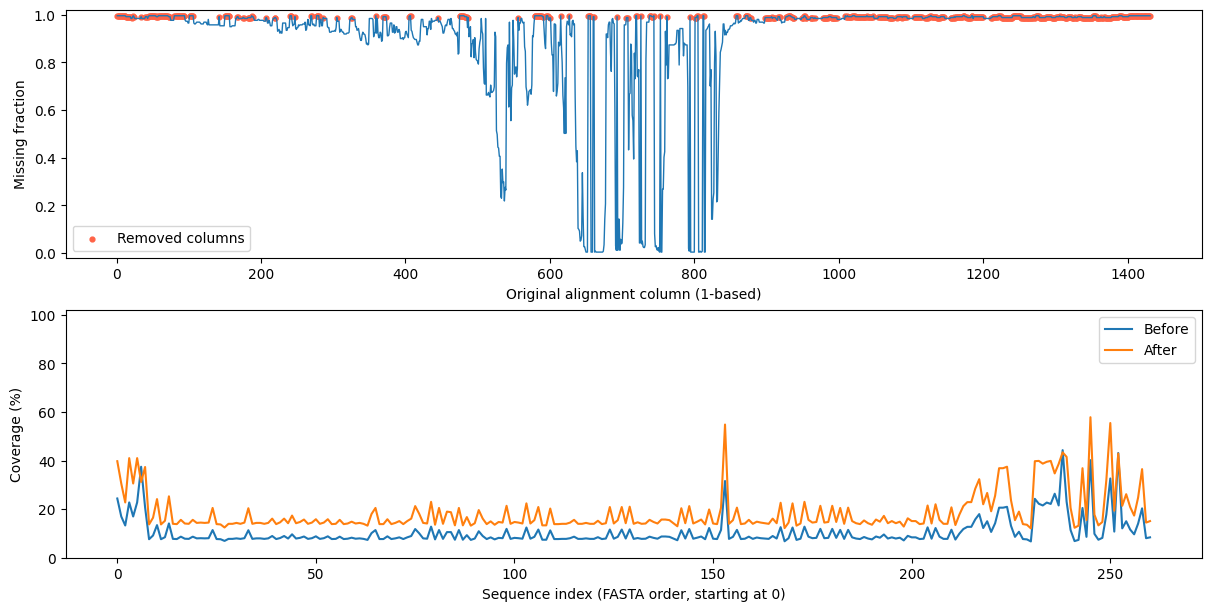

# ClipKIT trimming summary
Protein: CytC-homologs-Aln2 | Run: smart_gap_v1 | Execution: 20261008T012143Z_44c18487

Sequences: 261 before and after.
Columns: 1431 before; 795 retained; 636 removed.
Retained: 55.6%.
Mode: smart-gap; ClipKIT: 2.7.0.

Review sequence_coverage.csv and column_map.csv before sending the cleaned FASTA to Pete.
No sequences were automatically deleted. Original-column coordinates are 1-based.

Review sequences below 50% cleaned coverage: ['WP_011748139.1__txid266__CytC__h1', 'WP_011229026.1__txid300852__CytC__h1', 'WP_011228667.1__txid300852__CytC__h2', 'WP_011228651.1__txid300852__CytC__h3', 'WP_014630378.1__txid798128__CytC__h1', 'WP_014629280.1__txid798128__CytC__h2', 'WP_014630591.1__txid798128__CytC__h3', 'WP_013066897.1__txid272942__CytC__h1', 'WP_012164237.1__txid155978__CytC__h1', 'WP_238549240.1__txid155978__CytC__h2', 'WP_083776725.1__txid155978__CytC__h3', 'WP_010472213.1__txid310037__CytC__h1', 'WP_029315183.1__txid310037__CytC__h2', 'WP_262561610.1_

In [11]:
import matplotlib.pyplot as plt
from IPython.display import display
coverage = []
for ident, before, trimmed in zip(ids, seqs, after):
    a = sum(c not in "X?-" for c in before)
    b = sum(c not in "X?-" for c in trimmed)
    coverage.append({"sequence_id": ident, "original_residues": a, "retained_residues": b,
                     "original_coverage_pct": round(100*a/L, 2),
                     "cleaned_coverage_pct": round(100*b/len(kept), 2),
                     "review_below_50pct": b/len(kept) < 0.5})
save_csv(OUT_ROOT / "sequence_coverage.csv", coverage, list(coverage[0]))
save_csv(OUT_ROOT / "summary.csv", [manifest],
         list(manifest))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(range(1,L+1), [r["missing_fraction"] for r in site_rows], lw=1)
removed = [r for r in site_rows if r["action"] == "trim"]
axes[0].scatter([r["original_column"] for r in removed], [r["missing_fraction"] for r in removed],
                color="tomato", s=12, label="Removed columns")
axes[0].set(xlabel="Original alignment column (1-based)", ylabel="Missing fraction", ylim=(-.02,1.02))
axes[0].legend()
axes[1].plot([r["original_coverage_pct"] for r in coverage], label="Before")
axes[1].plot([r["cleaned_coverage_pct"] for r in coverage], label="After")
axes[1].set(xlabel="Sequence index (FASTA order, starting at 0)", ylabel="Coverage (%)", ylim=(0,102))
axes[1].legend()
fig.savefig(REPORT_ROOT / "trimming_overview.png", dpi=180)
fig.savefig(REPORT_ROOT / "trimming_overview.pdf")
plt.show()
report = f"""# ClipKIT trimming summary
Protein: {QUERY_NAME} | Run: {RUN_LABEL} | Execution: {execution}

Sequences: {N} before and after.
Columns: {L} before; {len(kept)} retained; {L-len(kept)} removed.
Retained: {100*len(kept)/L:.1f}%.
Mode: {MODE}; ClipKIT: {CLIPKIT_VERSION}.

Review sequence_coverage.csv and column_map.csv before sending the cleaned FASTA to Pete.
No sequences were automatically deleted. Original-column coordinates are 1-based.
"""
(REPORT_ROOT / "summary.md").write_text(report)
print(report)
flagged = [r["sequence_id"] for r in coverage if r["review_below_50pct"]]
print("Review sequences below 50% cleaned coverage:", flagged or "None")
if len(kept)/L < 0.5:
    print("REVIEW: More than half the original columns were removed.")


## 6. Save the handoff package and optionally download

The ZIP contains your cleaned FASTA, original and normalized inputs, site log, column mapping, coverage table, manifest, software environment record, and figures. Transfer **the cleaned aligned FASTA** to Pete for RAxML. Do not remove gaps. Shared databases are not bundled.

Drive holds a persistent copy; downloading to your computer is optional. This notebook does not submit a Pete job or upload anything to GitHub.

In [12]:
import zipfile
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True, check=True)
(OUT_ROOT / "environment.txt").write_text(freeze.stdout)
archive = OUT_ROOT.parent / f"{execution}_ClipKIT_handoff.zip"
with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as z:
    for root, prefix in ((OUT_ROOT, "results"), (REPORT_ROOT, "reports")):
        for f in sorted(root.rglob("*")):
            if f.is_file(): z.write(f, str(Path(prefix) / f.relative_to(root)))
print("Cleaned FASTA:", OUT_ROOT / cleaned.name)
print("Handoff ZIP:", archive)
DOWNLOAD_TO_COMPUTER = False
if DOWNLOAD_TO_COMPUTER:
    from google.colab import files
    files.download(str(archive))


Cleaned FASTA: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/Alignment_Trimming_ClipKIT/CytC-homologs-Aln2/smart_gap_v1/20261008T012143Z_44c18487/CytC-homologs-Aln2_alignment_cleaned.fasta
Handoff ZIP: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/Alignment_Trimming_ClipKIT/CytC-homologs-Aln2/smart_gap_v1/20261008T012143Z_44c18487_ClipKIT_handoff.zip


## 7. Short answers and rerunning

1. How many columns were retained and removed?
2. Were removed columns concentrated at the ends or within the alignment?
3. Which sequences need coverage review, if any?
4. Why should confidently aligned variable sites not automatically be removed?
5. What limitation remains after gap-based trimming?

To compare settings, change `MODE` (and `GAP_THRESHOLD` for `gappy`) and `RUN_LABEL`, then rerun Sections 2–6. To change proteins, also change `QUERY_NAME` and `ALIGNMENT_FASTA`. Every execution is saved separately. Save your executed notebook copy on Drive for your report.

**References:** [ClipKIT documentation](https://jlsteenwyk.com/ClipKIT/) · [Source and version history](https://github.com/JLSteenwyk/ClipKIT) · [ClipKIT paper](https://doi.org/10.1371/journal.pbio.3001007)

The GitHub copy should have cleared outputs. A Canvas Open in Colab link can be created once its final GitHub path is selected; the notebook itself is not published by this draft.